# Thanjavur Crop Recommendation - Clean ML Pipeline

This notebook contains only the production flow:
1. Imports
2. Data preprocessing
3. Dataset creation
4. Train/test split
5. Model training
6. Results
7. Crop prediction

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
import glob

from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, average_precision_score, roc_auc_score, classification_report

# Optional advanced boosting libraries
try:
    from catboost import CatBoostClassifier
except ImportError:
    CatBoostClassifier = None

try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None

try:
    from lightgbm import LGBMClassifier
except ImportError:
    LGBMClassifier = None

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

data_path = Path(r'c:\Users\tanis\Documents\Project 2\Project---2\Data')
print(f'Data path: {data_path}')

Data path: c:\Users\tanis\Documents\Project 2\Project---2\Data


## 2. Data Preprocessing

In [ ]:
# Load Thanjavur soil data
soil_file = data_path / 'Soil Data ( District Wise)' / 'CSV Format' / 'THANJAVUR.csv'
soil_data = pd.read_csv(soil_file)

# Load weather data
weather_file = data_path / 'Weather Data (District Wise)' / 'weather_data_all_blocks.csv'
weather_data = pd.read_csv(weather_file)
thanjavur_weather = weather_data[weather_data['district'] == 'Thanjavur'].copy()

# Helper for consistent joins across market, requirements, and area/yield files
def normalize_crop_name(name):
    if pd.isna(name):
        return ''
    text = str(name).strip().lower()
    replacements = {
        '-': '',
        '_': '',
        ' ': '',
        '(': '',
        ')': '',
        '/': '',
        '.': ''
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    return text

# Load all crop CSVs (market data)
crop_files = glob.glob(str(data_path / '3_Cleaned CSVs' / '*.csv'))
crop_data_dict = {}
for file in crop_files:
    crop_name = Path(file).stem
    try:
        df = pd.read_csv(file)
        crop_data_dict[crop_name] = df
    except:
        pass

# Load crop requirements
requirements_file = data_path / 'crop_requirements.csv'
crop_requirements_df = pd.read_csv(requirements_file)
crop_requirements_df['crop_key'] = crop_requirements_df['Crop'].apply(normalize_crop_name)

req_level_map = {'low': 1, 'medium': 2, 'high': 3}
for col in ['N_Req', 'P_Req', 'K_Req']:
    crop_requirements_df[f'{col}_level'] = crop_requirements_df[col].astype(str).str.strip().str.lower().map(req_level_map).fillna(2)

# Load crop area/yield history and aggregate by crop
area_yield_file = data_path / 'Crop Area And Yield Data.csv'
area_yield_df = pd.read_csv(area_yield_file)
area_yield_df['crop_key'] = area_yield_df['Crop'].apply(normalize_crop_name)
area_yield_df['Area Under'] = pd.to_numeric(area_yield_df['Area Under'], errors='coerce')
area_yield_df['Yield'] = pd.to_numeric(area_yield_df['Yield'], errors='coerce')

crop_area_yield_agg = (
    area_yield_df.groupby('crop_key')[['Area Under', 'Yield']]
    .median()
    .rename(columns={'Area Under': 'area_median', 'Yield': 'yield_median'})
    .reset_index()
)
crop_area_yield_agg['yield_per_area'] = (
    crop_area_yield_agg['yield_median'] / crop_area_yield_agg['area_median'].replace(0, np.nan)
).replace([np.inf, -np.inf], np.nan)

print(f"Soil data shape: {soil_data.shape}")
print(f"Weather data shape: {thanjavur_weather.shape}")
print(f"Crops loaded: {len(crop_data_dict)}")
print(f"Crop requirements loaded: {crop_requirements_df.shape[0]}")
print(f"Crop area/yield rows loaded: {area_yield_df.shape[0]}")

Soil data shape: (14, 34)
Weather data shape: (14, 37)
Crops loaded: 29
Crop requirements loaded: 27
Crop area/yield rows loaded: 54


## 3. Dataset Creation

In [3]:
# Create soil features
soil_summary = soil_data.groupby('District')[[
    'n_High', 'n_Medium', 'n_Low',
    'p_High', 'p_Medium', 'p_Low',
    'k_High', 'k_Medium', 'k_Low',
    'pH_Neutral', 'pH_Acidic', 'pH_Alkaline',
    'EC_Saline', 'EC_NonSaline',
    'OC_High', 'OC_Medium', 'OC_Low'
]].mean()

# Create weather features
weather_features = thanjavur_weather[[
    'temp_max_mean', 'temp_min_mean', 'temp_mean_annual',
    'total_rainfall_mm', 'avg_daily_rainfall_mm',
    'humidity_max_mean', 'humidity_min_mean',
    'rainy_days', 'wind_speed_max_mean'
]].mean()

print("Soil Features:")
print(soil_summary.loc['THANJAVUR'])
print("\nWeather Features:")
print(weather_features)

Soil Features:
n_High           0.013571
n_Medium         0.260714
n_Low           99.726429
p_High           6.068571
p_Medium        18.387857
p_Low           75.544286
k_High          26.740000
k_Medium        49.789286
k_Low           23.466429
pH_Neutral      97.823571
pH_Acidic        1.422143
pH_Alkaline      0.754286
EC_Saline        0.430000
EC_NonSaline    99.570000
OC_High          6.740714
OC_Medium       29.910714
OC_Low          63.349286
Name: THANJAVUR, dtype: float64

Weather Features:
temp_max_mean              32.439779
temp_min_mean              24.267143
temp_mean_annual           27.765000
total_rainfall_mm        1412.035714
avg_daily_rainfall_mm       3.858029
humidity_max_mean          91.387779
humidity_min_mean          52.704343
rainy_days                235.071429
wind_speed_max_mean        18.904993
dtype: float64


## 4. Train/Test Split

In [4]:
# Create a dataset where EACH TRANSACTION is a separate row
# - Features: soil + weather + crop requirements + historical area/yield (EXCLUDING price for suitability)
# - Target: HIGH-PERFORMING transaction (1) vs lower-performing (0)

tf_soil = soil_summary.loc['THANJAVUR']

# Build lookup tables for crop-specific features
requirements_lookup = crop_requirements_df.set_index('crop_key')[
    ['N_Req_level', 'P_Req_level', 'K_Req_level', 'Rainfall', 'Temp']
]
area_yield_lookup = crop_area_yield_agg.set_index('crop_key')[
    ['area_median', 'yield_median', 'yield_per_area']
]

default_req = pd.Series({
    'N_Req_level': 2.0,
    'P_Req_level': 2.0,
    'K_Req_level': 2.0,
    'Rainfall': crop_requirements_df['Rainfall'].median(),
    'Temp': crop_requirements_df['Temp'].median(),
})
default_area_yield = pd.Series({
    'area_median': crop_area_yield_agg['area_median'].median(),
    'yield_median': crop_area_yield_agg['yield_median'].median(),
    'yield_per_area': crop_area_yield_agg['yield_per_area'].median(),
})

# Function to extract year from filename (if available)
def extract_year_from_filename(crop_name):
    import re
    years = re.findall(r'\b(20\d{2})\b', crop_name)
    if years:
        return int(years[0])
    return 2020

# Build feature matrix - ONE ROW PER TRANSACTION
training_data = []
crop_list_records = []
year_records = []
target_proxy_records = []

# Get all district soil data for mapping
district_soil_data = soil_summary

print('Building enriched multi-row dataset with HIGH-PERFORMANCE target...')
total_records = 0
req_matches = 0
area_yield_matches = 0

for crop_name, crop_df in crop_data_dict.items():
    base_crop = crop_name.rsplit('-', 1)[0] if any(y in crop_name for y in ['-2015-2019', '-2019-2022', '-2022-2025', '-2024-2025', '-2025']) else crop_name
    crop_key = normalize_crop_name(base_crop)

    file_year = extract_year_from_filename(crop_name)

    req_values = requirements_lookup.loc[crop_key] if crop_key in requirements_lookup.index else default_req
    ay_values = area_yield_lookup.loc[crop_key] if crop_key in area_yield_lookup.index else default_area_yield

    if crop_key in requirements_lookup.index:
        req_matches += 1
    if crop_key in area_yield_lookup.index:
        area_yield_matches += 1

    for _, row in crop_df.iterrows():
        year = file_year
        district = row['District Name']

        try:
            if district in district_soil_data.index:
                soil_features = list(district_soil_data.loc[district].values)
            else:
                soil_features = list(tf_soil.values)
        except:
            soil_features = list(tf_soil.values)

        req_features = [
            float(req_values['N_Req_level']),
            float(req_values['P_Req_level']),
            float(req_values['K_Req_level']),
            float(req_values['Rainfall']),
            float(req_values['Temp']),
        ]

        ay_features = [
            float(ay_values['area_median']) if not pd.isna(ay_values['area_median']) else float(default_area_yield['area_median']),
            float(ay_values['yield_median']) if not pd.isna(ay_values['yield_median']) else float(default_area_yield['yield_median']),
            float(ay_values['yield_per_area']) if not pd.isna(ay_values['yield_per_area']) else float(default_area_yield['yield_per_area']),
        ]

        # NO PRICE in model features (deweighting price for suitability learning)
        features = soil_features + list(weather_features.values) + req_features + ay_features

        # Build target proxy from market opportunity: price * crop historical yield
        price_value = pd.to_numeric(row.get('Modal Price (Rs./Quintal)', np.nan), errors='coerce')
        yield_for_proxy = ay_features[1]
        if pd.isna(price_value):
            target_proxy = np.nan
        else:
            target_proxy = float(price_value) * float(yield_for_proxy)

        training_data.append(features)
        crop_list_records.append(base_crop)
        year_records.append(year)
        target_proxy_records.append(target_proxy)
        total_records += 1

# Convert to arrays
X = np.array(training_data)

# Create HIGH-PERFORMING target from top quartile of revenue proxy
proxy_series = pd.Series(target_proxy_records, dtype='float64')
if proxy_series.notna().sum() == 0:
    raise ValueError('No valid price-based target proxy values found.')

proxy_fill_value = float(proxy_series.median())
proxy_series = proxy_series.fillna(proxy_fill_value)
high_perf_threshold = float(proxy_series.quantile(0.75))
y = (proxy_series >= high_perf_threshold).astype(int).to_numpy()

# Create DataFrame for reference
requirement_feature_names = ['req_n_level', 'req_p_level', 'req_k_level', 'req_rainfall', 'req_temp']
area_yield_feature_names = ['hist_area_median', 'hist_yield_median', 'hist_yield_per_area']
feature_names = list(tf_soil.index) + list(weather_features.index) + requirement_feature_names + area_yield_feature_names

X_df = pd.DataFrame(X, columns=feature_names)
X_df['crop'] = crop_list_records
X_df['success'] = y
X_df['year'] = year_records
X_df['target_revenue_proxy'] = proxy_series.values

# For crop list, get unique crops
crop_list = list(set(crop_list_records))

print('\nDataset created with HIGH-PERFORMANCE target:')
print(f'   Total transaction records: {total_records}')
print(f'   Dataset shape: {X.shape}')
print(f'   Unique crops: {len(crop_list)}')
print(f'   High-performance threshold (75th percentile proxy): {high_perf_threshold:.2f}')
print(f'   Classes: {np.bincount(y)}')
print(f'   - High-performing (1): {int(sum(y))} records ({sum(y)/len(y):.1%})')
print(f'   - Lower-performing (0): {int(len(y) - sum(y))} records ({(len(y)-sum(y))/len(y):.1%})')
print(f'   Features per record: {len(feature_names)} (PRICE EXCLUDED)')
print('\nExternal feature coverage:')
print(f'   - Crops matched to requirements: {req_matches}/{len(crop_data_dict)}')
print(f'   - Crops matched to area/yield: {area_yield_matches}/{len(crop_data_dict)}')
print('\nYear distribution (from filenames):')
year_dist = pd.Series(year_records).value_counts().sort_index()
print(year_dist.to_string())


Building enriched multi-row dataset with HIGH-PERFORMANCE target...

Dataset created with HIGH-PERFORMANCE target:
   Total transaction records: 798447
   Dataset shape: (798447, 34)
   Unique crops: 29
   High-performance threshold (75th percentile proxy): 50884600.00
   Classes: [598311 200136]
   - High-performing (1): 200136 records (25.1%)
   - Lower-performing (0): 598311 records (74.9%)
   Features per record: 34 (PRICE EXCLUDED)

External feature coverage:
   - Crops matched to requirements: 25/29
   - Crops matched to area/yield: 25/29

Year distribution (from filenames):
2020    798447


## 5. Model Training

In [5]:
# Train/test split: stratified random split (80/20)
print('Applying STRATIFIED RANDOM split (80% train / 20% test)...')

X_source = X_df.drop(columns=['year', 'target_revenue_proxy'])

split_idx = np.arange(len(X_df))
train_idx, test_idx = train_test_split(
    split_idx, test_size=0.2, random_state=42, stratify=y
)

y_train = y[train_idx]
y_test = y[test_idx]

print('\nTRAIN/TEST SPLIT RESULTS (Stratified Random):')
print(f'   Train rows (80%): {len(train_idx):,}')
print(f'   Test rows (20%):  {len(test_idx):,}')
print(f'   Train class distribution: {np.bincount(y_train)}')
print(f'   Test class distribution:  {np.bincount(y_test)}')
print(f'   Train high-performance prevalence: {sum(y_train)/len(y_train):.1%}')
print(f'   Test high-performance prevalence:  {sum(y_test)/len(y_test):.1%}')


Applying STRATIFIED RANDOM split (80% train / 20% test)...

TRAIN/TEST SPLIT RESULTS (Stratified Random):
   Train rows (80%): 638,757
   Test rows (20%):  159,690
   Train class distribution: [478648 160109]
   Test class distribution:  [119663  40027]
   Train high-performance prevalence: 25.1%
   Test high-performance prevalence:  25.1%


In [6]:
# Define feature sets for modeling (PRICE DEWEIGHTED - only agro-climatic features)
soil_cols = list(tf_soil.index)
weather_cols = list(weather_features.index)
req_cols = requirement_feature_names
ay_cols = area_yield_feature_names

feature_sets = {
    'soil_weather': soil_cols + weather_cols,
    'soil_weather_requirements': soil_cols + weather_cols + req_cols,
    'soil_weather_req_area_yield': soil_cols + weather_cols + req_cols + ay_cols,
}

print('Feature sets defined (PRICE-DEWEIGHTED for pure agro-climatic suitability):')
for set_name, cols in feature_sets.items():
    print(f'  - {set_name}: {len(cols)} features')


Feature sets defined (PRICE-DEWEIGHTED for pure agro-climatic suitability):
  - soil_weather: 26 features
  - soil_weather_requirements: 31 features
  - soil_weather_req_area_yield: 34 features


## 6. Results

In [7]:
# Shared model-training state and helpers

def get_scale_pos_weight():
    if 'y_train' not in globals():
        return 1.0
    neg_count = int((y_train == 0).sum())
    pos_count = int((y_train == 1).sum())
    return (neg_count / pos_count) if pos_count > 0 else 1.0

scale_pos_weight = get_scale_pos_weight()
results = []
trained_models = {}
skipped_runs = []
svm_train_cap = 20000
missing_models = []

# Cross-validation controls
cv_folds = 5
cv_max_rows = 80000

def sample_for_cv(X_data, y_data, max_rows=80000, random_state=42):
    if len(X_data) <= max_rows:
        return X_data, y_data

    rng = np.random.default_rng(random_state)
    pos_idx = np.where(y_data == 1)[0]
    neg_idx = np.where(y_data == 0)[0]

    n_pos = min(len(pos_idx), max_rows // 2)
    n_neg = min(len(neg_idx), max_rows - n_pos)

    pos_sel = rng.choice(pos_idx, size=n_pos, replace=False)
    neg_sel = rng.choice(neg_idx, size=n_neg, replace=False)
    sel = np.concatenate([pos_sel, neg_sel])
    rng.shuffle(sel)
    return X_data[sel], y_data[sel]

def run_cross_validation(model_name, model, X_train_model, y_train_model):
    if len(np.unique(y_train_model)) < 2:
        return None

    X_cv, y_cv = sample_for_cv(X_train_model, y_train_model, max_rows=cv_max_rows, random_state=42)

    if len(np.unique(y_cv)) < 2:
        return None

    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    fold_acc = []
    fold_f1 = []
    fold_pr_auc = []
    fold_roc_auc = []

    for fold_train_idx, fold_val_idx in skf.split(X_cv, y_cv):
        X_fold_train = X_cv[fold_train_idx]
        y_fold_train = y_cv[fold_train_idx]
        X_fold_val = X_cv[fold_val_idx]
        y_fold_val = y_cv[fold_val_idx]

        cv_model = clone(model)

        # Keep CV logging quiet for CatBoost
        if model_name == 'CatBoost':
            try:
                cv_model.set_params(verbose=False)
            except Exception:
                pass

        cv_model.fit(X_fold_train, y_fold_train)
        y_val_pred = cv_model.predict(X_fold_val)
        y_val_proba = cv_model.predict_proba(X_fold_val)[:, 1]

        fold_acc.append(accuracy_score(y_fold_val, y_val_pred))
        fold_f1.append(f1_score(y_fold_val, y_val_pred, zero_division=0))
        fold_pr_auc.append(average_precision_score(y_fold_val, y_val_proba))
        fold_roc_auc.append(roc_auc_score(y_fold_val, y_val_proba))

    return {
        'cv_rows': int(len(y_cv)),
        'cv_accuracy_mean': float(np.mean(fold_acc)),
        'cv_accuracy_std': float(np.std(fold_acc)),
        'cv_f1_mean': float(np.mean(fold_f1)),
        'cv_f1_std': float(np.std(fold_f1)),
        'cv_pr_auc_mean': float(np.mean(fold_pr_auc)),
        'cv_pr_auc_std': float(np.std(fold_pr_auc)),
        'cv_roc_auc_mean': float(np.mean(fold_roc_auc)),
        'cv_roc_auc_std': float(np.std(fold_roc_auc)),
    }

def train_model_block(model_name, model, feature_set_names=None):
    selected_sets = feature_set_names if feature_set_names is not None else list(feature_sets.keys())
    print(f'\n=== Starting {model_name} ===')

    for feature_set_name in selected_sets:
        cols = feature_sets[feature_set_name]
        print(f'[{model_name}] Preparing feature set: {feature_set_name}')

        X_train_raw = X_source.iloc[train_idx][cols].values
        X_test_raw = X_source.iloc[test_idx][cols].values

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_raw)
        X_test_scaled = scaler.transform(X_test_raw)

        use_scaled = model_name in ['LogisticRegression', 'SVM']
        X_train_use = X_train_scaled if use_scaled else X_train_raw
        X_test_use = X_test_scaled if use_scaled else X_test_raw

        if np.all(np.nanstd(X_train_use, axis=0) < 1e-12):
            message = f'{model_name} on {feature_set_name}: constant features'
            print(f'[{model_name}] Skipping - {message}')
            skipped_runs.append(message)
            continue

        if model_name == 'SVM' and len(X_train_use) > svm_train_cap:
            pos_idx = np.where(y_train == 1)[0]
            neg_idx = np.where(y_train == 0)[0]
            svm_pos_n = min(len(pos_idx), svm_train_cap // 2)
            svm_neg_n = min(len(neg_idx), svm_train_cap - svm_pos_n)
            svm_pos_sel = np.random.choice(pos_idx, size=svm_pos_n, replace=False)
            svm_neg_sel = np.random.choice(neg_idx, size=svm_neg_n, replace=False)
            svm_idx = np.concatenate([svm_pos_sel, svm_neg_sel])
            np.random.shuffle(svm_idx)
            X_train_fit = X_train_use[svm_idx]
            y_train_fit = y_train[svm_idx]
            print(f'[{model_name}] SVM checkpoint: using {len(svm_idx):,} rows for fit')
        else:
            X_train_fit = X_train_use
            y_train_fit = y_train

        print(f'[{model_name}] Running {cv_folds}-fold CV (up to {cv_max_rows:,} rows) ...')
        cv_stats = None
        try:
            cv_stats = run_cross_validation(model_name, model, X_train_fit, y_train_fit)
            if cv_stats is not None:
                print(
                    f"[{model_name}] CV PR-AUC={cv_stats['cv_pr_auc_mean']:.4f} (+/- {cv_stats['cv_pr_auc_std']:.4f}) | "
                    f"CV ROC-AUC={cv_stats['cv_roc_auc_mean']:.4f} | CV F1={cv_stats['cv_f1_mean']:.4f}"
                )
        except Exception as ex:
            message = f"{model_name} CV on {feature_set_name}: {str(ex)[:120]}"
            print(f'[{model_name}] CV failed - {message}')
            skipped_runs.append(message)

        print(f'[{model_name}] Fitting on {len(X_train_fit):,} rows; testing on {len(X_test_use):,} rows')
        try:
            model.fit(X_train_fit, y_train_fit)
            y_pred = model.predict(X_test_use)
            y_proba = model.predict_proba(X_test_use)[:, 1]
        except Exception as ex:
            message = f"{model_name} on {feature_set_name}: {str(ex)[:120]}"
            print(f'[{model_name}] Failed - {message}')
            skipped_runs.append(message)
            continue

        accuracy_value = accuracy_score(y_test, y_pred)
        f1_value = f1_score(y_test, y_pred, zero_division=0)
        pr_auc_value = average_precision_score(y_test, y_proba)
        roc_auc_value = roc_auc_score(y_test, y_proba)

        row_result = {
            'feature_set': feature_set_name,
            'model': model_name,
            'accuracy': accuracy_value,
            'f1': f1_value,
            'pr_auc': pr_auc_value,
            'roc_auc': roc_auc_value,
            'cv_rows': np.nan,
            'cv_accuracy_mean': np.nan,
            'cv_accuracy_std': np.nan,
            'cv_f1_mean': np.nan,
            'cv_f1_std': np.nan,
            'cv_pr_auc_mean': np.nan,
            'cv_pr_auc_std': np.nan,
            'cv_roc_auc_mean': np.nan,
            'cv_roc_auc_std': np.nan,
        }

        if cv_stats is not None:
            row_result.update(cv_stats)

        results.append(row_result)

        trained_models[(feature_set_name, model_name)] = {
            'model': model,
            'scaler': scaler if use_scaled else None,
            'features': cols,
        }

        print(
            f'[{model_name}] Done | holdout accuracy={accuracy_value:.4f} | '
            f'holdout f1={f1_value:.4f} | holdout pr_auc={pr_auc_value:.4f} | holdout roc_auc={roc_auc_value:.4f}'
        )

    print(f'=== Finished {model_name} ===')

def finalize_results():
    global results_df, best_row, best_key, best_pipeline, best_by_model, ensemble_members, accuracy_rank
    if len(results) == 0:
        raise ValueError('No model completed training. Check feature matrix and model availability.')

    results_df = pd.DataFrame(results).sort_values(['pr_auc', 'f1', 'accuracy'], ascending=False).reset_index(drop=True)
    best_row = results_df.iloc[0]
    best_key = (best_row['feature_set'], best_row['model'])
    best_pipeline = trained_models[best_key]

    best_by_model = (
        results_df.sort_values(['pr_auc', 'f1', 'accuracy'], ascending=False)
        .groupby('model', as_index=False)
        .first()
        .sort_values('pr_auc', ascending=False)
        .reset_index(drop=True)
    )

    ensemble_members = {}
    for _, row in best_by_model.iterrows():
        member_key = (row['feature_set'], row['model'])
        ensemble_members[row['model']] = trained_models[member_key]

    print('\nModel training completed.')
    if missing_models:
        print(f"Optional libraries missing, skipped models: {', '.join(missing_models)}")
    if skipped_runs:
        print('\nSkipped model/feature-set runs:')
        for item in skipped_runs:
            print(f'- {item}')

    print('\nLeaderboard (sorted by holdout PR-AUC):')
    print(results_df[['model', 'feature_set', 'accuracy', 'f1', 'pr_auc', 'roc_auc']].to_string(index=False))

    cv_ready = results_df[results_df['cv_pr_auc_mean'].notna()].copy()
    if len(cv_ready) > 0:
        print('\nCross-validation summary (sorted by CV PR-AUC mean):')
        cv_view = cv_ready.sort_values('cv_pr_auc_mean', ascending=False)
        print(cv_view[['model', 'feature_set', 'cv_pr_auc_mean', 'cv_pr_auc_std', 'cv_f1_mean', 'cv_roc_auc_mean', 'cv_rows']].to_string(index=False))

    print('\nAccuracy ranking for every model (descending):')
    accuracy_rank = results_df.sort_values(['accuracy', 'pr_auc', 'f1'], ascending=[False, False, False]).reset_index(drop=True)
    print(accuracy_rank[['model', 'feature_set', 'accuracy', 'f1', 'pr_auc', 'roc_auc']].to_string(index=False))

    print('\nBest configuration (by holdout PR-AUC):')
    print(f"Feature set: {best_row['feature_set']}")
    print(f"Model: {best_row['model']}")
    print(
        f"PR-AUC: {best_row['pr_auc']:.4f} | F1: {best_row['f1']:.4f} | "
        f"Accuracy: {best_row['accuracy']:.4f} | ROC-AUC: {best_row['roc_auc']:.4f}"
    )

    print('\nEnsemble members (best variant of each model):')
    print(best_by_model[['model', 'feature_set', 'pr_auc', 'f1', 'accuracy', 'roc_auc']].to_string(index=False))

    plt.figure(figsize=(14, 6))
    plot_df = results_df.head(15).copy()
    plot_df['label'] = plot_df['model'] + ' | ' + plot_df['feature_set']
    sns.barplot(data=plot_df, y='label', x='pr_auc', palette='viridis')
    plt.title('Top 15 Experiments by Holdout PR-AUC')
    plt.xlabel('PR-AUC')
    plt.ylabel('Model | Feature Set')
    plt.tight_layout()
    plt.show()

### Model Cells
Each cell below trains one model family and prints checkpoints so you can track progress as the notebook runs.

In [8]:
print('Starting Random Forest training block...')
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=14,
    min_samples_leaf=2,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1,
)
train_model_block('RandomForest', rf_model)
print('Random Forest block complete.')

Starting Random Forest training block...

=== Starting RandomForest ===
[RandomForest] Preparing feature set: soil_weather
[RandomForest] Skipping - RandomForest on soil_weather: constant features
[RandomForest] Preparing feature set: soil_weather_requirements
[RandomForest] Running 5-fold CV (up to 80,000 rows) ...
[RandomForest] CV PR-AUC=0.9121 (+/- 0.0013) | CV ROC-AUC=0.9312 | CV F1=0.8606
[RandomForest] Fitting on 638,757 rows; testing on 159,690 rows
[RandomForest] Done | holdout accuracy=0.7692 | holdout f1=0.6820 | holdout pr_auc=0.8058 | holdout roc_auc=0.9318
[RandomForest] Preparing feature set: soil_weather_req_area_yield
[RandomForest] Running 5-fold CV (up to 80,000 rows) ...
[RandomForest] CV PR-AUC=0.9270 (+/- 0.0011) | CV ROC-AUC=0.9437 | CV F1=0.8736
[RandomForest] Fitting on 638,757 rows; testing on 159,690 rows
[RandomForest] Done | holdout accuracy=0.8251 | holdout f1=0.7301 | holdout pr_auc=0.8323 | holdout roc_auc=0.9442
=== Finished RandomForest ===
Random Fore

In [9]:
print('Starting Gradient Boosting training block...')
gb_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
)
train_model_block('GradientBoosting', gb_model)
print('Gradient Boosting block complete.')

Starting Gradient Boosting training block...

=== Starting GradientBoosting ===
[GradientBoosting] Preparing feature set: soil_weather
[GradientBoosting] Skipping - GradientBoosting on soil_weather: constant features
[GradientBoosting] Preparing feature set: soil_weather_requirements
[GradientBoosting] Running 5-fold CV (up to 80,000 rows) ...
[GradientBoosting] CV PR-AUC=0.9121 (+/- 0.0013) | CV ROC-AUC=0.9312 | CV F1=0.8606
[GradientBoosting] Fitting on 638,757 rows; testing on 159,690 rows
[GradientBoosting] Done | holdout accuracy=0.8824 | holdout f1=0.7006 | holdout pr_auc=0.8058 | holdout roc_auc=0.9318
[GradientBoosting] Preparing feature set: soil_weather_req_area_yield
[GradientBoosting] Running 5-fold CV (up to 80,000 rows) ...
[GradientBoosting] CV PR-AUC=0.9270 (+/- 0.0010) | CV ROC-AUC=0.9437 | CV F1=0.8736
[GradientBoosting] Fitting on 638,757 rows; testing on 159,690 rows
[GradientBoosting] Done | holdout accuracy=0.8824 | holdout f1=0.7007 | holdout pr_auc=0.8323 | hold

In [10]:
print('Starting Logistic Regression training block...')
lr_model = LogisticRegression(
    max_iter=1200,
    class_weight='balanced',
    solver='lbfgs',
    random_state=42,
)
train_model_block('LogisticRegression', lr_model)
print('Logistic Regression block complete.')

Starting Logistic Regression training block...

=== Starting LogisticRegression ===
[LogisticRegression] Preparing feature set: soil_weather
[LogisticRegression] Skipping - LogisticRegression on soil_weather: constant features
[LogisticRegression] Preparing feature set: soil_weather_requirements
[LogisticRegression] Running 5-fold CV (up to 80,000 rows) ...
[LogisticRegression] CV PR-AUC=0.8152 (+/- 0.0028) | CV ROC-AUC=0.8692 | CV F1=0.8260
[LogisticRegression] Fitting on 638,757 rows; testing on 159,690 rows
[LogisticRegression] Done | holdout accuracy=0.8076 | holdout f1=0.6903 | holdout pr_auc=0.6148 | holdout roc_auc=0.8701
[LogisticRegression] Preparing feature set: soil_weather_req_area_yield
[LogisticRegression] Running 5-fold CV (up to 80,000 rows) ...
[LogisticRegression] CV PR-AUC=0.9190 (+/- 0.0011) | CV ROC-AUC=0.9336 | CV F1=0.8328
[LogisticRegression] Fitting on 638,757 rows; testing on 159,690 rows
[LogisticRegression] Done | holdout accuracy=0.8067 | holdout f1=0.6930 

In [11]:
print('Starting SVM training block...')
svm_model = SVC(
    C=1.5,
    kernel='rbf',
    gamma='scale',
    class_weight='balanced',
    probability=True,
    random_state=42,
)
train_model_block('SVM', svm_model)
print('SVM block complete.')

Starting SVM training block...

=== Starting SVM ===
[SVM] Preparing feature set: soil_weather
[SVM] Skipping - SVM on soil_weather: constant features
[SVM] Preparing feature set: soil_weather_requirements
[SVM] SVM checkpoint: using 20,000 rows for fit
[SVM] Running 5-fold CV (up to 80,000 rows) ...
[SVM] CV PR-AUC=0.7281 (+/- 0.0476) | CV ROC-AUC=0.8116 | CV F1=0.8626
[SVM] Fitting on 20,000 rows; testing on 159,690 rows
[SVM] Done | holdout accuracy=0.7692 | holdout f1=0.6820 | holdout pr_auc=0.6273 | holdout roc_auc=0.8846
[SVM] Preparing feature set: soil_weather_req_area_yield
[SVM] SVM checkpoint: using 20,000 rows for fit
[SVM] Running 5-fold CV (up to 80,000 rows) ...
[SVM] CV PR-AUC=0.8136 (+/- 0.0558) | CV ROC-AUC=0.8705 | CV F1=0.8803
[SVM] Fitting on 20,000 rows; testing on 159,690 rows
[SVM] Done | holdout accuracy=0.8251 | holdout f1=0.7301 | holdout pr_auc=0.6885 | holdout roc_auc=0.9084
=== Finished SVM ===
SVM block complete.


In [12]:
print('Starting CatBoost training block...')
scale_pos_weight = get_scale_pos_weight()
if CatBoostClassifier is not None:
    catboost_model = CatBoostClassifier(
        iterations=260,
        depth=6,
        learning_rate=0.05,
        loss_function='Logloss',
        eval_metric='PRAUC',
        class_weights=[1.0, scale_pos_weight],
        random_seed=42,
        verbose=50,
    )
    train_model_block('CatBoost', catboost_model)
else:
    missing_models.append('CatBoost')
    print('CatBoost is not installed; skipping this block.')
print('CatBoost block complete.')

Starting CatBoost training block...

=== Starting CatBoost ===
[CatBoost] Preparing feature set: soil_weather
[CatBoost] Skipping - CatBoost on soil_weather: constant features
[CatBoost] Preparing feature set: soil_weather_requirements
[CatBoost] Running 5-fold CV (up to 80,000 rows) ...
[CatBoost] CV failed - CatBoost CV on soil_weather_requirements: Cannot clone object CatBoostClassifier(class_weights=[1.0, 2.9895133940003373], depth=6, eval_metric='PRAUC', iterations
[CatBoost] Fitting on 638,757 rows; testing on 159,690 rows
0:	learn: 0.9283298	total: 207ms	remaining: 53.7s
50:	learn: 0.9302520	total: 3.37s	remaining: 13.8s
100:	learn: 0.9306156	total: 6.36s	remaining: 10s
150:	learn: 0.9315872	total: 9.11s	remaining: 6.57s
200:	learn: 0.9315875	total: 11.8s	remaining: 3.47s
250:	learn: 0.9315875	total: 14.5s	remaining: 521ms
259:	learn: 0.9315875	total: 15s	remaining: 0us
[CatBoost] Done | holdout accuracy=0.7692 | holdout f1=0.6820 | holdout pr_auc=0.8058 | holdout roc_auc=0.9318

In [13]:
print('Starting XGBoost training block...')
scale_pos_weight = get_scale_pos_weight()
if XGBClassifier is not None:
    xgb_model = XGBClassifier(
        n_estimators=260,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        objective='binary:logistic',
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
    )
    train_model_block('XGBoost', xgb_model)
else:
    missing_models.append('XGBoost')
    print('XGBoost is not installed; skipping this block.')
print('XGBoost block complete.')

Starting XGBoost training block...

=== Starting XGBoost ===
[XGBoost] Preparing feature set: soil_weather


[XGBoost] Skipping - XGBoost on soil_weather: constant features
[XGBoost] Preparing feature set: soil_weather_requirements
[XGBoost] Running 5-fold CV (up to 80,000 rows) ...
[XGBoost] CV PR-AUC=0.9121 (+/- 0.0013) | CV ROC-AUC=0.9312 | CV F1=0.8590
[XGBoost] Fitting on 638,757 rows; testing on 159,690 rows
[XGBoost] Done | holdout accuracy=0.7692 | holdout f1=0.6820 | holdout pr_auc=0.8058 | holdout roc_auc=0.9318
[XGBoost] Preparing feature set: soil_weather_req_area_yield
[XGBoost] Running 5-fold CV (up to 80,000 rows) ...
[XGBoost] CV PR-AUC=0.9270 (+/- 0.0010) | CV ROC-AUC=0.9437 | CV F1=0.8676
[XGBoost] Fitting on 638,757 rows; testing on 159,690 rows
[XGBoost] Done | holdout accuracy=0.8251 | holdout f1=0.7301 | holdout pr_auc=0.8323 | holdout roc_auc=0.9442
=== Finished XGBoost ===
XGBoost block complete.


In [14]:
print('Starting LightGBM training block...')
scale_pos_weight = get_scale_pos_weight()
if LGBMClassifier is not None:
    lgbm_model = LGBMClassifier(
        n_estimators=260,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        subsample=0.9,
        colsample_bytree=0.9,
        class_weight={0: 1.0, 1: scale_pos_weight},
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )
    train_model_block('LightGBM', lgbm_model)
else:
    missing_models.append('LightGBM')
    print('LightGBM is not installed; skipping this block.')
print('LightGBM block complete.')

Starting LightGBM training block...

=== Starting LightGBM ===
[LightGBM] Preparing feature set: soil_weather
[LightGBM] Skipping - LightGBM on soil_weather: constant features
[LightGBM] Preparing feature set: soil_weather_requirements
[LightGBM] Running 5-fold CV (up to 80,000 rows) ...
[LightGBM] CV PR-AUC=0.9121 (+/- 0.0013) | CV ROC-AUC=0.9312 | CV F1=0.8590
[LightGBM] Fitting on 638,757 rows; testing on 159,690 rows
[LightGBM] Done | holdout accuracy=0.7692 | holdout f1=0.6820 | holdout pr_auc=0.8058 | holdout roc_auc=0.9318
[LightGBM] Preparing feature set: soil_weather_req_area_yield
[LightGBM] Running 5-fold CV (up to 80,000 rows) ...
[LightGBM] CV PR-AUC=0.9270 (+/- 0.0010) | CV ROC-AUC=0.9437 | CV F1=0.8667
[LightGBM] Fitting on 638,757 rows; testing on 159,690 rows
[LightGBM] Done | holdout accuracy=0.8251 | holdout f1=0.7301 | holdout pr_auc=0.8323 | holdout roc_auc=0.9442
=== Finished LightGBM ===
LightGBM block complete.


Finalizing training results and ensemble members...

Model training completed.

Skipped model/feature-set runs:
- RandomForest on soil_weather: constant features
- GradientBoosting on soil_weather: constant features
- LogisticRegression on soil_weather: constant features
- SVM on soil_weather: constant features
- CatBoost on soil_weather: constant features
- CatBoost CV on soil_weather_requirements: Cannot clone object CatBoostClassifier(class_weights=[1.0, 2.9895133940003373], depth=6, eval_metric='PRAUC', iterations
- CatBoost CV on soil_weather_req_area_yield: Cannot clone object CatBoostClassifier(class_weights=[1.0, 2.9895133940003373], depth=6, eval_metric='PRAUC', iterations
- XGBoost on soil_weather: constant features
- LightGBM on soil_weather: constant features

Leaderboard (sorted by holdout PR-AUC):
             model                 feature_set  accuracy       f1   pr_auc  roc_auc
      RandomForest soil_weather_req_area_yield  0.825080 0.730139 0.832300 0.944154
         

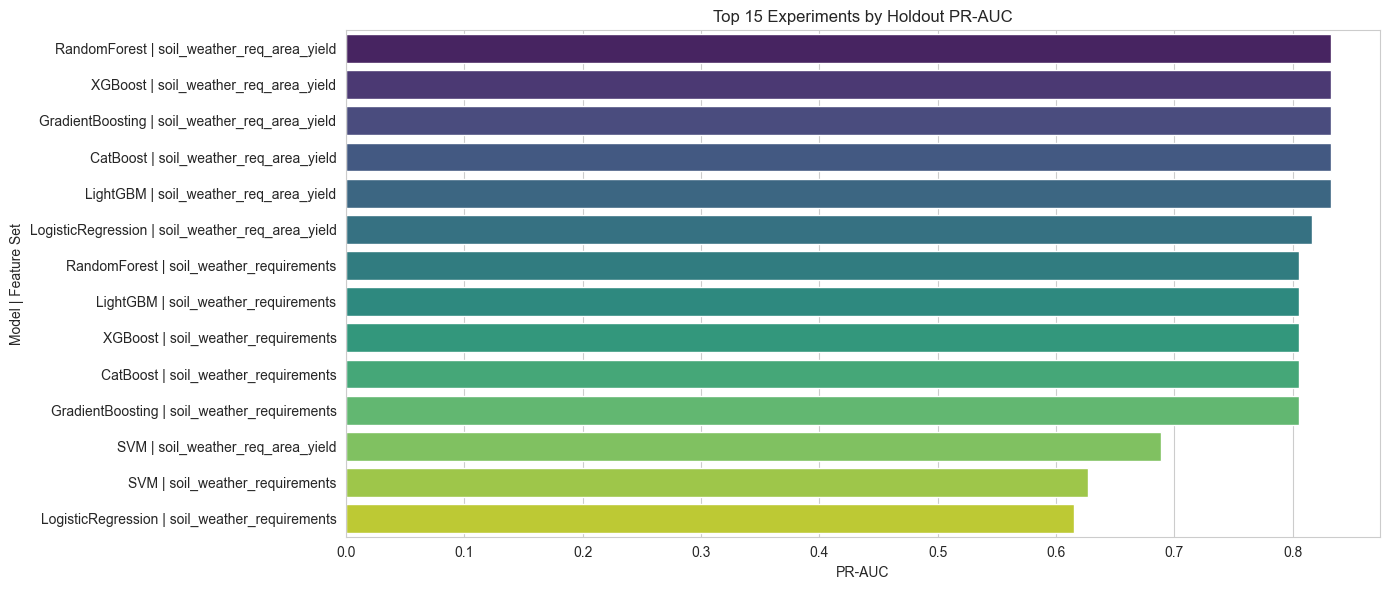

Training finalization complete.


In [15]:
print('Finalizing training results and ensemble members...')
finalize_results()
print('Training finalization complete.')

Results summary by feature set (best model per set):
                feature_set        model   pr_auc  roc_auc       f1  accuracy
soil_weather_req_area_yield RandomForest 0.832300 0.944154 0.730139  0.825080
  soil_weather_requirements RandomForest 0.805807 0.931819 0.681970  0.769228

Cross-validation leaderboard (CV PR-AUC mean):
             model                 feature_set  cv_pr_auc_mean  cv_pr_auc_std  cv_f1_mean  cv_roc_auc_mean
          LightGBM soil_weather_req_area_yield        0.926999       0.001047    0.866705         0.943680
  GradientBoosting soil_weather_req_area_yield        0.926999       0.001047    0.873634         0.943684
           XGBoost soil_weather_req_area_yield        0.926999       0.001047    0.867585         0.943679
      RandomForest soil_weather_req_area_yield        0.926996       0.001051    0.873634         0.943680
LogisticRegression soil_weather_req_area_yield        0.918988       0.001131    0.832776         0.933617
           XGBoost   so

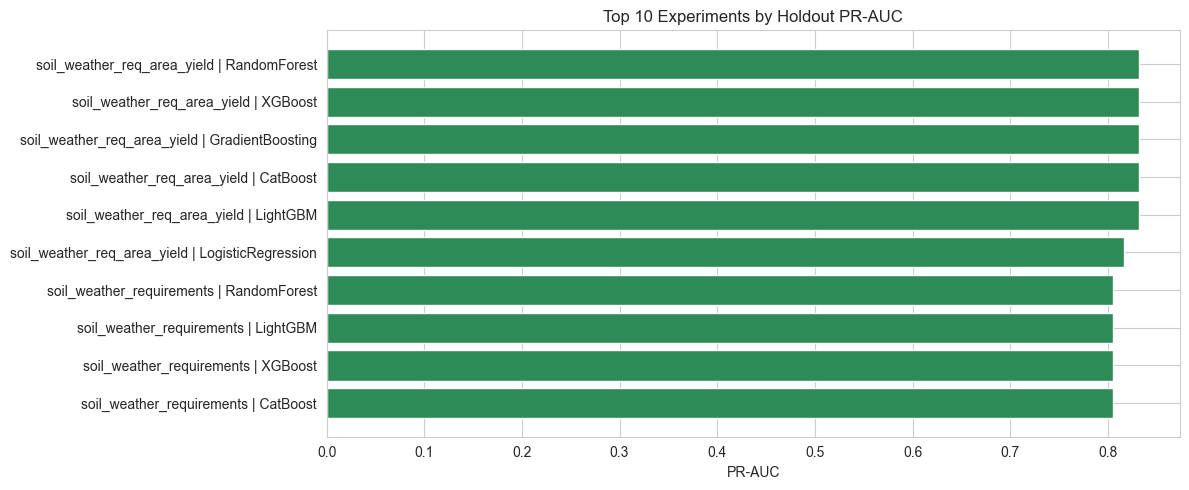


Classification report for best pipeline:
                   precision    recall  f1-score   support

Lower Performance       0.98      0.79      0.87    119663
 High Performance       0.60      0.94      0.73     40027

         accuracy                           0.83    159690
        macro avg       0.79      0.86      0.80    159690
     weighted avg       0.88      0.83      0.84    159690



In [16]:
# Results summary and quick visualization
print('Results summary by feature set (best model per set):')
best_by_set = results_df.sort_values(['pr_auc', 'f1'], ascending=False).groupby('feature_set', as_index=False).first()

primary_cols = ['feature_set', 'model', 'pr_auc', 'roc_auc', 'f1', 'accuracy']
available_primary_cols = [c for c in primary_cols if c in best_by_set.columns]
print(best_by_set[available_primary_cols].to_string(index=False))

if 'cv_pr_auc_mean' in results_df.columns:
    cv_ready = results_df[results_df['cv_pr_auc_mean'].notna()].copy()
    if len(cv_ready) > 0:
        print('\nCross-validation leaderboard (CV PR-AUC mean):')
        cv_cols = ['model', 'feature_set', 'cv_pr_auc_mean', 'cv_pr_auc_std', 'cv_f1_mean', 'cv_roc_auc_mean']
        available_cv_cols = [c for c in cv_cols if c in cv_ready.columns]
        cv_view = cv_ready.sort_values('cv_pr_auc_mean', ascending=False).head(10)
        print(cv_view[available_cv_cols].to_string(index=False))

plt.figure(figsize=(12, 5))
plot_df = results_df.head(10).copy()
labels = plot_df['feature_set'] + ' | ' + plot_df['model']
plt.barh(labels[::-1], plot_df['pr_auc'][::-1], color='#2E8B57')
plt.xlabel('PR-AUC')
plt.title('Top 10 Experiments by Holdout PR-AUC')
plt.tight_layout()
plt.show()

# Classification report for best pipeline
X_test_best = X_source.iloc[test_idx][best_pipeline['features']].values
if best_pipeline['scaler'] is not None:
    X_test_best_use = best_pipeline['scaler'].transform(X_test_best)
else:
    X_test_best_use = X_test_best
y_pred_best = best_pipeline['model'].predict(X_test_best_use)

print('\nClassification report for best pipeline:')
print(classification_report(y_test, y_pred_best, target_names=['Lower Performance', 'High Performance']))

## 7. Prediction

In [17]:
# Three prediction rankings: SEPARATE CONCERNS
# 1. HIGH-PERFORMANCE PROBABILITY: Ensemble of non-price features
# 2. YIELD RANK: Historical productivity potential (0-100 normalized)
# 3. PROFIT RANK: Market profitability proxy (Price x Yield)

print('=' * 80)
print('PREDICTION RANKINGS (3 separate objectives):')
print('=' * 80)

# Build ensemble probability from best member of each trained model family
ensemble_proba_parts = []
for member_name, member in ensemble_members.items():
    X_member = X_df[member['features']].values
    if member['scaler'] is not None:
        X_member = member['scaler'].transform(X_member)
    member_proba = member['model'].predict_proba(X_member)[:, 1]
    ensemble_proba_parts.append(member_proba)

if len(ensemble_proba_parts) == 0:
    raise ValueError('No ensemble members available. Run training cell first.')

ensemble_proba_all = np.mean(np.vstack(ensemble_proba_parts), axis=0)

prediction_df = pd.DataFrame({
    'Crop': X_df['crop'],
    'Actual_High_Performance': X_df['success'],
    'Ensemble_High_Performance_Probability': ensemble_proba_all,
})

print('\nRANKING 1: HIGH-PERFORMANCE PROBABILITY (non-price model output)')
print('-' * 80)
performance_rank = prediction_df.groupby('Crop', as_index=False).agg(
    Mean_High_Performance_Prob=('Ensemble_High_Performance_Probability', 'mean'),
    Max_High_Performance_Prob=('Ensemble_High_Performance_Probability', 'max'),
    Seen_As_High_Performing=('Actual_High_Performance', 'max'),
    Samples=('Crop', 'count'),
).sort_values('Max_High_Performance_Prob', ascending=False)
print(performance_rank.head(15).to_string(index=False))

print('\n\nRANKING 2: YIELD POTENTIAL (Historical productivity, 0-100 scale)')
print('-' * 80)
yield_rank = crop_area_yield_agg.copy()
yield_rank['Crop'] = yield_rank['crop_key']
yield_rank = yield_rank[['Crop', 'area_median', 'yield_median', 'yield_per_area']].copy()
yield_rank['Yield_Potential'] = (yield_rank['yield_median'].rank() / len(yield_rank)) * 100
yield_rank['Area_Potential'] = (yield_rank['area_median'].rank() / len(yield_rank)) * 100
yield_rank['Yield_Combined_Score'] = (0.7 * yield_rank['Yield_Potential'] + 0.3 * yield_rank['Area_Potential'])
yield_rank = yield_rank.sort_values('Yield_Combined_Score', ascending=False)
print(yield_rank.head(15).to_string(index=False))

print('\n\nRANKING 3: PROFIT PROXY (Price x Yield market opportunity)')
print('-' * 80)
profit_lookup = []
for crop_name, crop_df in crop_data_dict.items():
    base_crop = crop_name.rsplit('-', 1)[0] if any(y in crop_name for y in ['-2015-2019', '-2019-2022', '-2022-2025', '-2024-2025', '-2025']) else crop_name
    prices = pd.to_numeric(crop_df['Modal Price (Rs./Quintal)'], errors='coerce').dropna()
    if len(prices) == 0:
        continue
    crop_key = normalize_crop_name(base_crop)
    yield_row = crop_area_yield_agg[crop_area_yield_agg['crop_key'] == crop_key]
    yield_value = float(yield_row['yield_median'].iloc[0]) if len(yield_row) > 0 and pd.notna(yield_row['yield_median'].iloc[0]) else np.nan
    profit_lookup.append({
        'Crop': base_crop,
        'Avg_Price': prices.mean(),
        'Median_Price': prices.median(),
        'Price_Std': prices.std(),
        'Records': len(prices),
        'Yield_Median': yield_value,
    })

profit_rank = pd.DataFrame(profit_lookup)
profit_rank['Gross_Revenue_Proxy'] = profit_rank['Avg_Price'] * profit_rank['Yield_Median']
profit_rank['Profit_Proxy_Score'] = (profit_rank['Gross_Revenue_Proxy'].rank() / len(profit_rank)) * 100
profit_rank = profit_rank.sort_values('Profit_Proxy_Score', ascending=False)
print(profit_rank.head(15).to_string(index=False))

print('\n' + '=' * 80)
print('INTERPRETATION GUIDE:')
print('=' * 80)
print('''
- HIGH PERFORMANCE PROBABILITY: Model-estimated chance of being top-performing (non-price features).
- HIGH YIELD POTENTIAL: Historically productive and scalable crop.
- HIGH PROFIT PROXY: Strong market revenue opportunity (price x yield).

Recommendation: prioritize crops that score high in both performance probability and yield,
then use profit proxy as the market viability filter.
''')
print(f"Ensemble members used: {', '.join(list(ensemble_members.keys()))}")

# Keep legacy name for compatibility with previous cells/users
suitability_rank = performance_rank.copy()


PREDICTION RANKINGS (3 separate objectives):

RANKING 1: HIGH-PERFORMANCE PROBABILITY (non-price model output)
--------------------------------------------------------------------------------
      Crop  Mean_High_Performance_Prob  Max_High_Performance_Prob  Seen_As_High_Performing  Samples
    Banana                    0.964121                   0.964121                        1    57099
   Tapioca                    0.961204                   0.961204                        1    30349
    Garlic                    0.960575                   0.960575                        1    25910
   Coconut                    0.661239                   0.661239                        1    91020
     Lemon                    0.645132                   0.645132                        1    52158
     Onion                    0.577012                   0.577012                        1    60885
     Guava                    0.375239                   0.375239                        1    36226
     Man